In [249]:
import pandas as pd

In [250]:
table4 = pd.read_excel('ตารางที่ 4 จำนวนผู้สมัครงานจำแนกตามประเภทอาชีพ(รายเดือน).xls', sheet_name=None, skiprows=1)
table9 = pd.read_excel('ตารางที่ 9 จำนวนผู้บรรจุงานจำแนกตามประเภทอาชีพ(รายเดือน).xlsx', sheet_name=None, skiprows=1)
table15 = pd.read_excel('ตารางที่ 15 จำนวนตำแหน่งงานจำแนกตามประเภทอาชีพ(รายเดือน).xlsx', sheet_name=None, skiprows=1)

## Data Cleaning Phase

In [251]:
print(list(table4.keys()))
print(list(table9.keys()))
print(list(table15.keys()))

['monthly', 'CSV', 'Data Dic']
['Monthly', 'CSV', 'Data Dic']
['Monthly', 'CSV', 'Data Dic']


In [252]:
#จำนวนผู้สมัคร ในแต่ละอาชีพ
df_applicant_career = table4['CSV']
#จำนวนผู้บรรจุ ในแต่ละอาชีพ
df_appointment_career = table9['CSV']
#จำนวนตำแหน่งงาน ในแต่ละอาชีพ
df_avaliable_career = table15['CSV']

ตรวจสอบข้อมูลในตาราง และแก้ Format Date

In [253]:
df_applicant_career.head()

,Year,Month,Total,1,2,3,4,5,6,7,8,9,T,X,0
0,2014,Jan,35064,989,1612,3174,5266,5855,224,2111,2175,13656,2.0,NaN,NaN
1,2014,Feb,45311,1233,2624,5094,7699,7835,259,2336,2385,15797,49.0,NaN,NaN
2,2014,Mar,47998,1178,2297,5020,8606,8556,159,2390,2492,17241,59.0,NaN,NaN
3,2014,Apr,49233,1183,2629,5004,8568,8581,200,2380,2667,17951,70.0,NaN,NaN
4,2014,May,45942,1191,2178,4411,7935,8109,178,2259,2644,17000,37.0,NaN,NaN


In [254]:
df_applicant_career['Date'] = pd.to_datetime(df_applicant_career['Year'].astype(str) + '-' + df_applicant_career['Month'], format='%Y-%b')
df_applicant_career = df_applicant_career.drop(columns=['Year', 'Month'])
df_applicant_career.head()

,Total,1,2,3,4,5,6,7,8,9,T,X,0,Date
0,35064,989,1612,3174,5266,5855,224,2111,2175,13656,2.0,NaN,NaN,2014-01-01
1,45311,1233,2624,5094,7699,7835,259,2336,2385,15797,49.0,NaN,NaN,2014-02-01
2,47998,1178,2297,5020,8606,8556,159,2390,2492,17241,59.0,NaN,NaN,2014-03-01
3,49233,1183,2629,5004,8568,8581,200,2380,2667,17951,70.0,NaN,NaN,2014-04-01
4,45942,1191,2178,4411,7935,8109,178,2259,2644,17000,37.0,NaN,NaN,2014-05-01


In [255]:
df_appointment_career.head()

,Year,Month,Total,1,2,3,4,5,6,7,8,9,0,T,X
0,2014,Jan,22260.0,373.0,998.0,2325.0,3864.0,3852.0,152.0,1228.0,1850.0,7614.0,NaN,4.0,0.0
1,2014,Feb,26286.0,531.0,1191.0,2908.0,5054.0,5050.0,55.0,1377.0,1593.0,8522.0,NaN,5.0,NaN
2,2014,Mar,30806.0,555.0,1464.0,3525.0,5737.0,5989.0,53.0,1444.0,2200.0,9834.0,NaN,5.0,NaN
3,2014,Apr,33290.0,558.0,1591.0,3500.0,6120.0,5866.0,50.0,1648.0,2594.0,11282.0,NaN,81.0,NaN
4,2014,May,27256.0,499.0,1222.0,3111.0,4790.0,5151.0,63.0,1698.0,1847.0,8874.0,NaN,1.0,NaN


In [256]:
df_appointment_career['Date'] = pd.to_datetime(df_appointment_career['Year'].astype(str) + '-' + df_appointment_career['Month'], format='%Y-%b')
df_appointment_career = df_appointment_career.drop(columns=['Year', 'Month'])
df_appointment_career.head()

,Total,1,2,3,4,5,6,7,8,9,0,T,X,Date
0,22260.0,373.0,998.0,2325.0,3864.0,3852.0,152.0,1228.0,1850.0,7614.0,NaN,4.0,0.0,2014-01-01
1,26286.0,531.0,1191.0,2908.0,5054.0,5050.0,55.0,1377.0,1593.0,8522.0,NaN,5.0,NaN,2014-02-01
2,30806.0,555.0,1464.0,3525.0,5737.0,5989.0,53.0,1444.0,2200.0,9834.0,NaN,5.0,NaN,2014-03-01
3,33290.0,558.0,1591.0,3500.0,6120.0,5866.0,50.0,1648.0,2594.0,11282.0,NaN,81.0,NaN,2014-04-01
4,27256.0,499.0,1222.0,3111.0,4790.0,5151.0,63.0,1698.0,1847.0,8874.0,NaN,1.0,NaN,2014-05-01


In [257]:
df_avaliable_career.head()

,Year,Month,Total,1,2,3,4,5,6,7,8,9,T,X
0,2014,Jan,41215,612,1455,3199,16324,5259,227,2706,2773,8652,8.0,NaN
1,2014,Feb,40067,507,1479,4005,14751,5835,64,2585,2181,8643,17.0,NaN
2,2014,Mar,36104,699,1905,4289,5847,7017,110,2245,2738,11228,26.0,NaN
3,2014,Apr,35337,696,1935,3912,5533,5767,92,2272,3094,11946,90.0,NaN
4,2014,May,27408,575,1343,3208,4431,5568,72,2280,1968,7963,0.0,NaN


In [258]:
df_avaliable_career['Date'] = pd.to_datetime(df_avaliable_career['Year'].astype(str) + '-' + df_avaliable_career['Month'], format='%Y-%b')
df_avaliable_career = df_avaliable_career.drop(columns=['Year', 'Month'])
df_avaliable_career.head()

,Total,1,2,3,4,5,6,7,8,9,T,X,Date
0,41215,612,1455,3199,16324,5259,227,2706,2773,8652,8.0,NaN,2014-01-01
1,40067,507,1479,4005,14751,5835,64,2585,2181,8643,17.0,NaN,2014-02-01
2,36104,699,1905,4289,5847,7017,110,2245,2738,11228,26.0,NaN,2014-03-01
3,35337,696,1935,3912,5533,5767,92,2272,3094,11946,90.0,NaN,2014-04-01
4,27408,575,1343,3208,4431,5568,72,2280,1968,7963,0.0,NaN,2014-05-01


ปรับเปลี่ยน index ของแถว (นำอาชีมาเป็น index และนำวันที่มาเป็นคอลลัมบ์)
และ เติมข้อมูล NaN ด้วย 0

In [259]:
df_applicant_career_t = df_applicant_career.set_index('Date').T
df_applicant_career_t = df_applicant_career_t.fillna(0)
df_applicant_career_t

Date,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,...,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01,2026-09-01,2026-10-01,2026-11-01,2026-12-01
Total,35064.0,45311.0,47998.0,49233.0,45942.0,52437.0,41890.0,36464.0,38171.0,34517.0,...,25245.0,23540.0,23292.0,21875.0,19152.0,16160.0,0.0,0.0,0.0,0.0
1,989.0,1233.0,1178.0,1183.0,1191.0,1442.0,1194.0,883.0,984.0,1047.0,...,497.0,547.0,599.0,498.0,465.0,405.0,0.0,0.0,0.0,0.0
2,1612.0,2624.0,2297.0,2629.0,2178.0,2335.0,1834.0,1435.0,1423.0,1514.0,...,1469.0,1150.0,1296.0,1325.0,1251.0,961.0,0.0,0.0,0.0,0.0
3,3174.0,5094.0,5020.0,5004.0,4411.0,4954.0,3908.0,3314.0,3475.0,2943.0,...,5261.0,4420.0,4421.0,4313.0,3813.0,3299.0,0.0,0.0,0.0,0.0
4,5266.0,7699.0,8606.0,8568.0,7935.0,9213.0,6896.0,5618.0,5767.0,5217.0,...,4116.0,3812.0,4051.0,3710.0,3412.0,2712.0,0.0,0.0,0.0,0.0
5,5855.0,7835.0,8556.0,8581.0,8109.0,9369.0,7801.0,6906.0,6701.0,6303.0,...,2785.0,2982.0,2702.0,2456.0,2029.0,1840.0,0.0,0.0,0.0,0.0
6,224.0,259.0,159.0,200.0,178.0,292.0,191.0,131.0,125.0,133.0,...,57.0,28.0,47.0,27.0,15.0,9.0,0.0,0.0,0.0,0.0
7,2111.0,2336.0,2390.0,2380.0,2259.0,2819.0,2093.0,1888.0,1931.0,1932.0,...,689.0,727.0,775.0,606.0,631.0,441.0,0.0,0.0,0.0,0.0
8,2175.0,2385.0,2492.0,2667.0,2644.0,2725.0,2688.0,2302.0,2521.0,2361.0,...,874.0,885.0,901.0,722.0,773.0,696.0,0.0,0.0,0.0,0.0
9,13656.0,15797.0,17241.0,17951.0,17000.0,19276.0,15284.0,13987.0,15241.0,13065.0,...,9497.0,8989.0,8500.0,8218.0,6763.0,5797.0,0.0,0.0,0.0,0.0


In [260]:
df_appointment_career_t = df_appointment_career.set_index('Date').T
df_appointment_career_t = df_appointment_career_t.fillna(0)
df_appointment_career_t

Date,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,...,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01,2026-09-01,2026-10-01,2026-11-01,2026-12-01
Total,22260.0,26286.0,30806.0,33290.0,27256.0,37833.0,35369.0,44380.0,53144.0,23683.0,...,17378.0,0.0,16051.0,16225.0,15308.0,12892.0,10068.0,0.0,0.0,0.0
1,373.0,531.0,555.0,558.0,499.0,496.0,623.0,627.0,755.0,393.0,...,119.0,0.0,177.0,285.0,258.0,157.0,145.0,0.0,0.0,0.0
2,998.0,1191.0,1464.0,1591.0,1222.0,1982.0,1671.0,2005.0,2421.0,894.0,...,616.0,0.0,372.0,444.0,453.0,368.0,223.0,0.0,0.0,0.0
3,2325.0,2908.0,3525.0,3500.0,3111.0,4198.0,3873.0,4946.0,5464.0,2477.0,...,2917.0,0.0,2445.0,2490.0,2674.0,2031.0,1761.0,0.0,0.0,0.0
4,3864.0,5054.0,5737.0,6120.0,4790.0,7348.0,6672.0,6981.0,9084.0,3986.0,...,2500.0,0.0,2226.0,2519.0,2310.0,2055.0,1533.0,0.0,0.0,0.0
5,3852.0,5050.0,5989.0,5866.0,5151.0,6729.0,7224.0,7588.0,8859.0,4482.0,...,2282.0,0.0,2399.0,2154.0,1890.0,1587.0,1384.0,0.0,0.0,0.0
6,152.0,55.0,53.0,50.0,63.0,94.0,89.0,192.0,77.0,25.0,...,34.0,0.0,5.0,24.0,13.0,17.0,4.0,0.0,0.0,0.0
7,1228.0,1377.0,1444.0,1648.0,1698.0,1854.0,1954.0,1865.0,2782.0,1105.0,...,412.0,0.0,417.0,471.0,383.0,439.0,264.0,0.0,0.0,0.0
8,1850.0,1593.0,2200.0,2594.0,1847.0,1748.0,2316.0,3245.0,3689.0,1250.0,...,552.0,0.0,614.0,503.0,442.0,481.0,391.0,0.0,0.0,0.0
9,7614.0,8522.0,9834.0,11282.0,8874.0,13381.0,10942.0,16931.0,19993.0,9070.0,...,7946.0,0.0,7396.0,7335.0,6885.0,5757.0,4363.0,0.0,0.0,0.0


In [261]:
df_avaliable_career_t = df_avaliable_career.set_index('Date').T
df_avaliable_career_t = df_avaliable_career_t.fillna(0)
df_avaliable_career_t

Date,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,...,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01,2026-09-01,2026-10-01,2026-11-01,2026-12-01
Total,41215.0,40067.0,36104.0,35337.0,27408.0,40947.0,37951.0,41154.0,51703.0,28735.0,...,33038.0,27269.0,25546.0,26297.0,23640.0,18828.0,0.0,0.0,0.0,0.0
1,612.0,507.0,699.0,696.0,575.0,563.0,678.0,563.0,757.0,760.0,...,392.0,384.0,422.0,424.0,328.0,349.0,0.0,0.0,0.0,0.0
2,1455.0,1479.0,1905.0,1935.0,1343.0,2463.0,1654.0,1661.0,2229.0,1211.0,...,1323.0,948.0,776.0,1226.0,848.0,732.0,0.0,0.0,0.0,0.0
3,3199.0,4005.0,4289.0,3912.0,3208.0,4746.0,4340.0,5115.0,5561.0,3166.0,...,6137.0,4457.0,3759.0,4354.0,4906.0,3324.0,0.0,0.0,0.0,0.0
4,16324.0,14751.0,5847.0,5533.0,4431.0,7492.0,6678.0,5769.0,8026.0,4586.0,...,3353.0,3489.0,2890.0,3198.0,3350.0,2197.0,0.0,0.0,0.0,0.0
5,5259.0,5835.0,7017.0,5767.0,5568.0,7129.0,7329.0,6744.0,8326.0,5371.0,...,4019.0,3570.0,2992.0,4517.0,3110.0,2733.0,0.0,0.0,0.0,0.0
6,227.0,64.0,110.0,92.0,72.0,211.0,75.0,53.0,72.0,94.0,...,50.0,24.0,47.0,58.0,41.0,22.0,0.0,0.0,0.0,0.0
7,2706.0,2585.0,2245.0,2272.0,2280.0,3254.0,3060.0,2383.0,3067.0,1862.0,...,2031.0,1203.0,1437.0,1280.0,974.0,826.0,0.0,0.0,0.0,0.0
8,2773.0,2181.0,2738.0,3094.0,1968.0,2145.0,3118.0,2949.0,3324.0,1790.0,...,1394.0,1099.0,1023.0,1011.0,1251.0,848.0,0.0,0.0,0.0,0.0
9,8652.0,8643.0,11228.0,11946.0,7963.0,12929.0,11008.0,15915.0,20302.0,9875.0,...,14339.0,12095.0,12200.0,10229.0,8832.0,7797.0,0.0,0.0,0.0,0.0


ดูเหมือนว่า อาชีพ 0(ทหาร) จะมีปัญหา เพราะไม่มีข้อมูลใน ตาราง df_avaliable_career

และ ตรวจสอบอาชีพ 0 และ X เพราะมีค่า 0 เป็นจำนวนมาก

และ อาชีพ T หรือ ฝึกงาน ดูไม่จำเป็นต่อข้อมูล

In [262]:
df_applicant_career_t.index = df_applicant_career_t.index.astype(str)
df_applicant_career_t.index

Index(['Total', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'T', 'X', '0'], dtype='object')

In [263]:
df_applicant_career_t.count()

,0
Date,
2014-01-01,13
2014-02-01,13
2014-03-01,13
2014-04-01,13
2014-05-01,13
...,...
2026-08-01,13
2026-09-01,13
2026-10-01,13


In [264]:
df_applicant_career_t.loc[:, df_applicant_career_t.loc['0'] == 0].count()

,0
Date,
2014-01-01,13
2014-02-01,13
2014-03-01,13
2014-04-01,13
2014-05-01,13
...,...
2026-08-01,13
2026-09-01,13
2026-10-01,13


In [265]:
df_applicant_career_t.loc[:, df_applicant_career_t.loc['X'] == 0].count()

,0
Date,
2014-01-01,13
2014-02-01,13
2014-03-01,13
2014-04-01,13
2014-05-01,13
...,...
2026-08-01,13
2026-09-01,13
2026-10-01,13


ตัดอาชีพ 0 และ X ออกเนื่องจากมีข้อมูลน้อยเกินไป

ตัดอาชีพ T และ Total ออกเพราะไม่จำเป็นต่อการทำนาย หรือวิเคราะห์

In [266]:
df_applicant_career_t.index = df_applicant_career_t.index.astype(str)
df_applicant_career_t = df_applicant_career_t.drop(index=['0', 'X', 'T', 'Total'])
df_applicant_career_t

Date,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,...,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01,2026-09-01,2026-10-01,2026-11-01,2026-12-01
1,989.0,1233.0,1178.0,1183.0,1191.0,1442.0,1194.0,883.0,984.0,1047.0,...,497.0,547.0,599.0,498.0,465.0,405.0,0.0,0.0,0.0,0.0
2,1612.0,2624.0,2297.0,2629.0,2178.0,2335.0,1834.0,1435.0,1423.0,1514.0,...,1469.0,1150.0,1296.0,1325.0,1251.0,961.0,0.0,0.0,0.0,0.0
3,3174.0,5094.0,5020.0,5004.0,4411.0,4954.0,3908.0,3314.0,3475.0,2943.0,...,5261.0,4420.0,4421.0,4313.0,3813.0,3299.0,0.0,0.0,0.0,0.0
4,5266.0,7699.0,8606.0,8568.0,7935.0,9213.0,6896.0,5618.0,5767.0,5217.0,...,4116.0,3812.0,4051.0,3710.0,3412.0,2712.0,0.0,0.0,0.0,0.0
5,5855.0,7835.0,8556.0,8581.0,8109.0,9369.0,7801.0,6906.0,6701.0,6303.0,...,2785.0,2982.0,2702.0,2456.0,2029.0,1840.0,0.0,0.0,0.0,0.0
6,224.0,259.0,159.0,200.0,178.0,292.0,191.0,131.0,125.0,133.0,...,57.0,28.0,47.0,27.0,15.0,9.0,0.0,0.0,0.0,0.0
7,2111.0,2336.0,2390.0,2380.0,2259.0,2819.0,2093.0,1888.0,1931.0,1932.0,...,689.0,727.0,775.0,606.0,631.0,441.0,0.0,0.0,0.0,0.0
8,2175.0,2385.0,2492.0,2667.0,2644.0,2725.0,2688.0,2302.0,2521.0,2361.0,...,874.0,885.0,901.0,722.0,773.0,696.0,0.0,0.0,0.0,0.0
9,13656.0,15797.0,17241.0,17951.0,17000.0,19276.0,15284.0,13987.0,15241.0,13065.0,...,9497.0,8989.0,8500.0,8218.0,6763.0,5797.0,0.0,0.0,0.0,0.0


In [267]:
df_appointment_career_t.index = df_appointment_career_t.index.astype(str)
df_appointment_career_t = df_appointment_career_t.drop(index=['0', 'X', 'T', 'Total'])
df_appointment_career_t

Date,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,...,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01,2026-09-01,2026-10-01,2026-11-01,2026-12-01
1,373.0,531.0,555.0,558.0,499.0,496.0,623.0,627.0,755.0,393.0,...,119.0,0.0,177.0,285.0,258.0,157.0,145.0,0.0,0.0,0.0
2,998.0,1191.0,1464.0,1591.0,1222.0,1982.0,1671.0,2005.0,2421.0,894.0,...,616.0,0.0,372.0,444.0,453.0,368.0,223.0,0.0,0.0,0.0
3,2325.0,2908.0,3525.0,3500.0,3111.0,4198.0,3873.0,4946.0,5464.0,2477.0,...,2917.0,0.0,2445.0,2490.0,2674.0,2031.0,1761.0,0.0,0.0,0.0
4,3864.0,5054.0,5737.0,6120.0,4790.0,7348.0,6672.0,6981.0,9084.0,3986.0,...,2500.0,0.0,2226.0,2519.0,2310.0,2055.0,1533.0,0.0,0.0,0.0
5,3852.0,5050.0,5989.0,5866.0,5151.0,6729.0,7224.0,7588.0,8859.0,4482.0,...,2282.0,0.0,2399.0,2154.0,1890.0,1587.0,1384.0,0.0,0.0,0.0
6,152.0,55.0,53.0,50.0,63.0,94.0,89.0,192.0,77.0,25.0,...,34.0,0.0,5.0,24.0,13.0,17.0,4.0,0.0,0.0,0.0
7,1228.0,1377.0,1444.0,1648.0,1698.0,1854.0,1954.0,1865.0,2782.0,1105.0,...,412.0,0.0,417.0,471.0,383.0,439.0,264.0,0.0,0.0,0.0
8,1850.0,1593.0,2200.0,2594.0,1847.0,1748.0,2316.0,3245.0,3689.0,1250.0,...,552.0,0.0,614.0,503.0,442.0,481.0,391.0,0.0,0.0,0.0
9,7614.0,8522.0,9834.0,11282.0,8874.0,13381.0,10942.0,16931.0,19993.0,9070.0,...,7946.0,0.0,7396.0,7335.0,6885.0,5757.0,4363.0,0.0,0.0,0.0


In [268]:
df_avaliable_career_t.index = df_avaliable_career_t.index.astype(str)
df_avaliable_career_t = df_avaliable_career_t.drop(index=['X', 'T', 'Total'])
df_avaliable_career_t

Date,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,...,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01,2026-09-01,2026-10-01,2026-11-01,2026-12-01
1,612.0,507.0,699.0,696.0,575.0,563.0,678.0,563.0,757.0,760.0,...,392.0,384.0,422.0,424.0,328.0,349.0,0.0,0.0,0.0,0.0
2,1455.0,1479.0,1905.0,1935.0,1343.0,2463.0,1654.0,1661.0,2229.0,1211.0,...,1323.0,948.0,776.0,1226.0,848.0,732.0,0.0,0.0,0.0,0.0
3,3199.0,4005.0,4289.0,3912.0,3208.0,4746.0,4340.0,5115.0,5561.0,3166.0,...,6137.0,4457.0,3759.0,4354.0,4906.0,3324.0,0.0,0.0,0.0,0.0
4,16324.0,14751.0,5847.0,5533.0,4431.0,7492.0,6678.0,5769.0,8026.0,4586.0,...,3353.0,3489.0,2890.0,3198.0,3350.0,2197.0,0.0,0.0,0.0,0.0
5,5259.0,5835.0,7017.0,5767.0,5568.0,7129.0,7329.0,6744.0,8326.0,5371.0,...,4019.0,3570.0,2992.0,4517.0,3110.0,2733.0,0.0,0.0,0.0,0.0
6,227.0,64.0,110.0,92.0,72.0,211.0,75.0,53.0,72.0,94.0,...,50.0,24.0,47.0,58.0,41.0,22.0,0.0,0.0,0.0,0.0
7,2706.0,2585.0,2245.0,2272.0,2280.0,3254.0,3060.0,2383.0,3067.0,1862.0,...,2031.0,1203.0,1437.0,1280.0,974.0,826.0,0.0,0.0,0.0,0.0
8,2773.0,2181.0,2738.0,3094.0,1968.0,2145.0,3118.0,2949.0,3324.0,1790.0,...,1394.0,1099.0,1023.0,1011.0,1251.0,848.0,0.0,0.0,0.0,0.0
9,8652.0,8643.0,11228.0,11946.0,7963.0,12929.0,11008.0,15915.0,20302.0,9875.0,...,14339.0,12095.0,12200.0,10229.0,8832.0,7797.0,0.0,0.0,0.0,0.0


ตัดข้อมูลตั้งแต่วันที่ 2026-09-01 เนื่องจากไม่มีข้อมูล

In [269]:
df_applicant_career_t = df_applicant_career_t.loc[:, :'2026-08-01']
df_applicant_career_t.head()

Date,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,...,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01
1,989.0,1233.0,1178.0,1183.0,1191.0,1442.0,1194.0,883.0,984.0,1047.0,...,641.0,598.0,847.0,816.0,497.0,547.0,599.0,498.0,465.0,405.0
2,1612.0,2624.0,2297.0,2629.0,2178.0,2335.0,1834.0,1435.0,1423.0,1514.0,...,1239.0,1337.0,2533.0,1647.0,1469.0,1150.0,1296.0,1325.0,1251.0,961.0
3,3174.0,5094.0,5020.0,5004.0,4411.0,4954.0,3908.0,3314.0,3475.0,2943.0,...,5261.0,5110.0,5117.0,5806.0,5261.0,4420.0,4421.0,4313.0,3813.0,3299.0
4,5266.0,7699.0,8606.0,8568.0,7935.0,9213.0,6896.0,5618.0,5767.0,5217.0,...,4184.0,4033.0,4394.0,4512.0,4116.0,3812.0,4051.0,3710.0,3412.0,2712.0
5,5855.0,7835.0,8556.0,8581.0,8109.0,9369.0,7801.0,6906.0,6701.0,6303.0,...,2426.0,2961.0,3143.0,3131.0,2785.0,2982.0,2702.0,2456.0,2029.0,1840.0


In [270]:
df_appointment_career_t = df_appointment_career_t.loc[:, :'2026-08-01']
df_appointment_career_t.head()

Date,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,...,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01
1,373.0,531.0,555.0,558.0,499.0,496.0,623.0,627.0,755.0,393.0,...,219.0,165.0,126.0,323.0,119.0,0.0,177.0,285.0,258.0,157.0
2,998.0,1191.0,1464.0,1591.0,1222.0,1982.0,1671.0,2005.0,2421.0,894.0,...,403.0,383.0,288.0,507.0,616.0,0.0,372.0,444.0,453.0,368.0
3,2325.0,2908.0,3525.0,3500.0,3111.0,4198.0,3873.0,4946.0,5464.0,2477.0,...,2851.0,2935.0,2207.0,3460.0,2917.0,0.0,2445.0,2490.0,2674.0,2031.0
4,3864.0,5054.0,5737.0,6120.0,4790.0,7348.0,6672.0,6981.0,9084.0,3986.0,...,2366.0,2401.0,1871.0,2484.0,2500.0,0.0,2226.0,2519.0,2310.0,2055.0
5,3852.0,5050.0,5989.0,5866.0,5151.0,6729.0,7224.0,7588.0,8859.0,4482.0,...,1995.0,2321.0,2612.0,2434.0,2282.0,0.0,2399.0,2154.0,1890.0,1587.0


In [271]:
df_avaliable_career_t = df_avaliable_career_t.loc[:, :'2026-08-01']
df_avaliable_career_t.head()

Date,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,...,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01
1,612.0,507.0,699.0,696.0,575.0,563.0,678.0,563.0,757.0,760.0,...,2228.0,4275.0,680.0,493.0,392.0,384.0,422.0,424.0,328.0,349.0
2,1455.0,1479.0,1905.0,1935.0,1343.0,2463.0,1654.0,1661.0,2229.0,1211.0,...,4570.0,3296.0,947.0,1185.0,1323.0,948.0,776.0,1226.0,848.0,732.0
3,3199.0,4005.0,4289.0,3912.0,3208.0,4746.0,4340.0,5115.0,5561.0,3166.0,...,10840.0,8692.0,5014.0,6680.0,6137.0,4457.0,3759.0,4354.0,4906.0,3324.0
4,16324.0,14751.0,5847.0,5533.0,4431.0,7492.0,6678.0,5769.0,8026.0,4586.0,...,8305.0,5971.0,3798.0,4454.0,3353.0,3489.0,2890.0,3198.0,3350.0,2197.0
5,5259.0,5835.0,7017.0,5767.0,5568.0,7129.0,7329.0,6744.0,8326.0,5371.0,...,6985.0,9498.0,4987.0,4854.0,4019.0,3570.0,2992.0,4517.0,3110.0,2733.0


ตรวจสอบว่าข้อมูลทั้ง 3 ชุดมีวันที่เหมือนกันครบถ้วนหรือไม่

In [272]:
dates_applicant = set(df_applicant_career['Date'])
dates_appointment = set(df_appointment_career['Date'])
dates_available = set(df_avaliable_career['Date'])

are_all_equal = (dates_applicant == dates_appointment == dates_available)
print("วันที่ทั้ง 3 ชุดตรงกันทั้งหมดหรือไม่:", are_all_equal)

if not are_all_equal:
    all_dates = dates_applicant | dates_appointment | dates_available
    print("\nวันที่ที่มีเฉพาะบาง DataFrame:")
    print("- ขาดใน Applicant:", all_dates - dates_applicant)
    print("- ขาดใน Appointment:", all_dates - dates_appointment)
    print("- ขาดใน Available:", all_dates - dates_available)

วันที่ทั้ง 3 ชุดตรงกันทั้งหมดหรือไม่: True


ตรวจสอบว่ามี "เดือน/วันที่หลุดหายไป" ในช่วงเวลาหรือไม่

In [273]:
min_date = df_applicant_career['Date'].min()
max_date = df_applicant_career['Date'].max()

full_months = pd.date_range(start=min_date, end=max_date, freq='MS')

missing_months = set(full_months) - set(df_applicant_career['Date'])

if len(missing_months) == 0:
    print(" ข้อมูลต่อเนื่องครบถ้วนทุกเดือน ไม่มีเดือนที่หายไป")
else:
    print(" มีเดือนที่ข้อมูลขาดหายไป ดังนี้:")
    print(sorted(list(missing_months)))

 ข้อมูลต่อเนื่องครบถ้วนทุกเดือน ไม่มีเดือนที่หายไป


ตรวจสอบว่ามีวันที่ "ไม่มีข้อมูลเลย"

In [274]:
zero_dates = df_applicant_career_t.columns[(df_applicant_career_t == 0).all(axis=0)]
print("วันที่ไม่มีข้อมูลเลย (เป็น 0 ทุกอาชีพ):", list(zero_dates))

zero_sum_dates = df_applicant_career_t.columns[df_applicant_career_t.astype(float).sum(axis=0) == 0]
print("วันที่ผลรวมผู้สมัครเป็น 0:", list(zero_sum_dates))

วันที่ไม่มีข้อมูลเลย (เป็น 0 ทุกอาชีพ): []
วันที่ผลรวมผู้สมัครเป็น 0: []


ทำการ Normalize ข้อมูลให้อยู่ในช่วง 0-1

In [275]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

def normalize_transposed_df(df):
    df_float = df.astype(float)
    scaled_array = scaler.fit_transform(df_float.T).T
    return pd.DataFrame(scaled_array, index=df.index, columns=df.columns)

df_applicant_t_norm = normalize_transposed_df(df_applicant_career_t)
df_appointment_t_norm = normalize_transposed_df(df_appointment_career_t)
df_avaliable_t_norm = normalize_transposed_df(df_avaliable_career_t)

In [276]:
df_applicant_t_norm.head()

Date,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,...,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01
1,0.406250,0.516757,0.491848,0.494112,0.497736,0.611413,0.499094,0.358243,0.403986,0.432518,...,0.248641,0.229167,0.341938,0.327899,0.183424,0.206069,0.229620,0.183877,0.168931,0.141757
2,0.292376,0.504936,0.436253,0.505986,0.411258,0.444234,0.339004,0.255198,0.252678,0.271792,...,0.214031,0.234615,0.485822,0.299727,0.262340,0.195337,0.226003,0.232094,0.216551,0.155640
3,0.335470,0.576797,0.567496,0.565485,0.490950,0.559201,0.427728,0.353067,0.373303,0.306435,...,0.597788,0.578808,0.579688,0.666290,0.597788,0.492081,0.492207,0.478632,0.415787,0.351181
4,0.517776,0.815027,0.925840,0.921197,0.843861,1.000000,0.716921,0.560782,0.578986,0.511790,...,0.385583,0.367135,0.411240,0.425657,0.377276,0.340134,0.369334,0.327673,0.291265,0.205742
5,0.558140,0.796722,0.883600,0.886613,0.829739,0.981564,0.792626,0.684781,0.660080,0.612122,...,0.144957,0.209423,0.231353,0.229907,0.188215,0.211953,0.178214,0.148572,0.097120,0.074346


In [277]:
df_appointment_t_norm.head()

Date,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,...,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01
1,0.366045,0.521099,0.544652,0.547596,0.489696,0.486752,0.611384,0.615309,0.740922,0.385672,...,0.214917,0.161923,0.123651,0.316977,0.116781,0.0,0.173700,0.279686,0.253189,0.154073
2,0.371418,0.443245,0.544846,0.592110,0.454782,0.737626,0.621883,0.746185,0.901005,0.332713,...,0.149981,0.142538,0.107183,0.188686,0.229252,0.0,0.138444,0.165240,0.168590,0.136956
3,0.425512,0.532211,0.645132,0.640556,0.569363,0.768302,0.708821,0.905198,1.000000,0.453331,...,0.521779,0.537152,0.403917,0.633236,0.533858,0.0,0.447474,0.455710,0.489385,0.371706
4,0.425363,0.556363,0.631550,0.673712,0.527301,0.808895,0.734478,0.768494,1.000000,0.438793,...,0.260458,0.264311,0.205967,0.273448,0.275209,0.0,0.245046,0.277301,0.254293,0.226222
5,0.434812,0.570042,0.676036,0.662151,0.581443,0.759567,0.815442,0.856530,1.000000,0.505926,...,0.225195,0.261993,0.294841,0.274749,0.257591,0.0,0.270798,0.243143,0.213342,0.179140


In [278]:
df_avaliable_t_norm.head()

Date,2014-01-01,2014-02-01,2014-03-01,2014-04-01,2014-05-01,2014-06-01,2014-07-01,2014-08-01,2014-09-01,2014-10-01,...,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01
1,0.027333,0.018583,0.034583,0.034333,0.024250,0.023250,0.032833,0.023250,0.039417,0.039667,...,0.162000,0.332583,0.033000,0.017417,0.009000,0.008333,0.011500,0.011667,0.003667,0.005417
2,0.065160,0.066705,0.094134,0.096066,0.057949,0.130062,0.077973,0.078424,0.114996,0.049449,...,0.265727,0.183697,0.032451,0.047775,0.056661,0.032516,0.021441,0.050415,0.026077,0.018608
3,0.032349,0.049492,0.055532,0.047514,0.032541,0.065252,0.056617,0.073100,0.082585,0.031647,...,0.194862,0.149177,0.070952,0.106385,0.094836,0.059105,0.044260,0.056914,0.068655,0.035008
4,0.546629,0.488417,0.158908,0.147287,0.106506,0.219784,0.189660,0.156021,0.239546,0.112242,...,0.249870,0.163496,0.083080,0.107357,0.066612,0.071645,0.049478,0.060876,0.066501,0.023832
5,0.078743,0.090784,0.115492,0.089362,0.085202,0.117833,0.122013,0.109785,0.142854,0.081084,...,0.114823,0.167353,0.073058,0.070277,0.052823,0.043437,0.031355,0.063233,0.033822,0.025941


# **พล็อตกราฟ เพื่อดูลักษณะการกระจายตัวของข้อมูล**

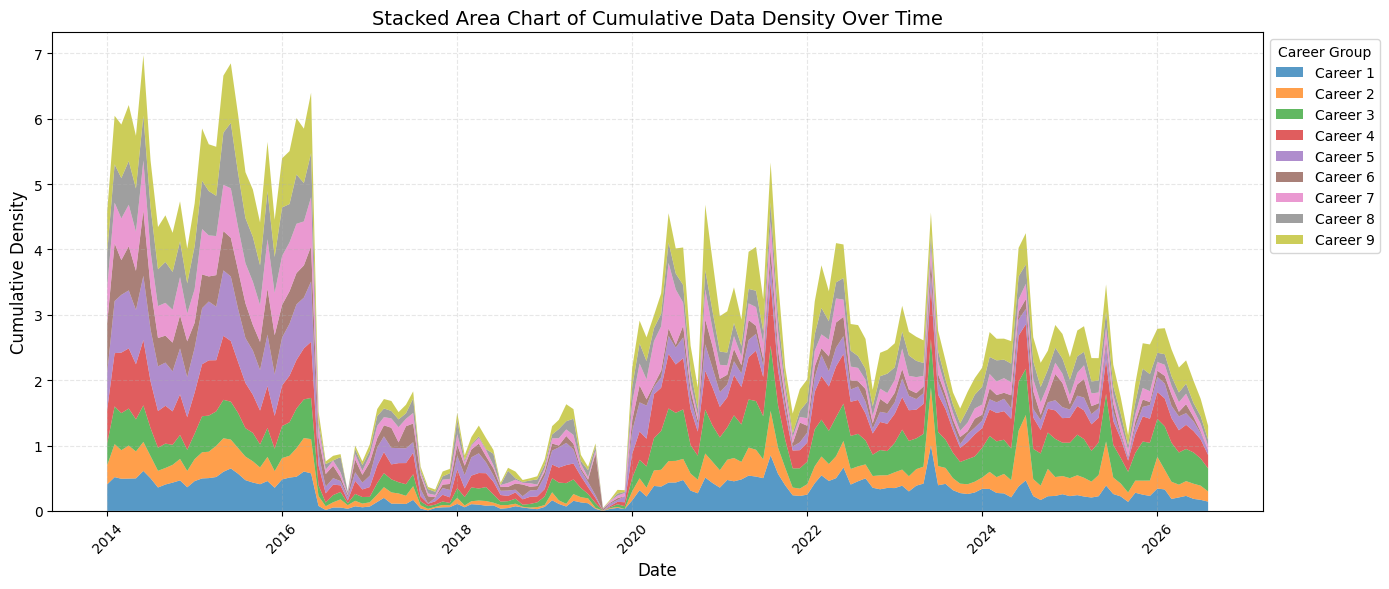

In [279]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot stacked area chart
plt.stackplot(
    df_applicant_t_norm.columns,
    df_applicant_t_norm.astype(float).values,
    labels=[f'Career {c}' for c in df_applicant_t_norm.index],
    alpha=0.75
)

plt.title('Stacked Area Chart of Cumulative Data Density Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Density', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Career Group')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

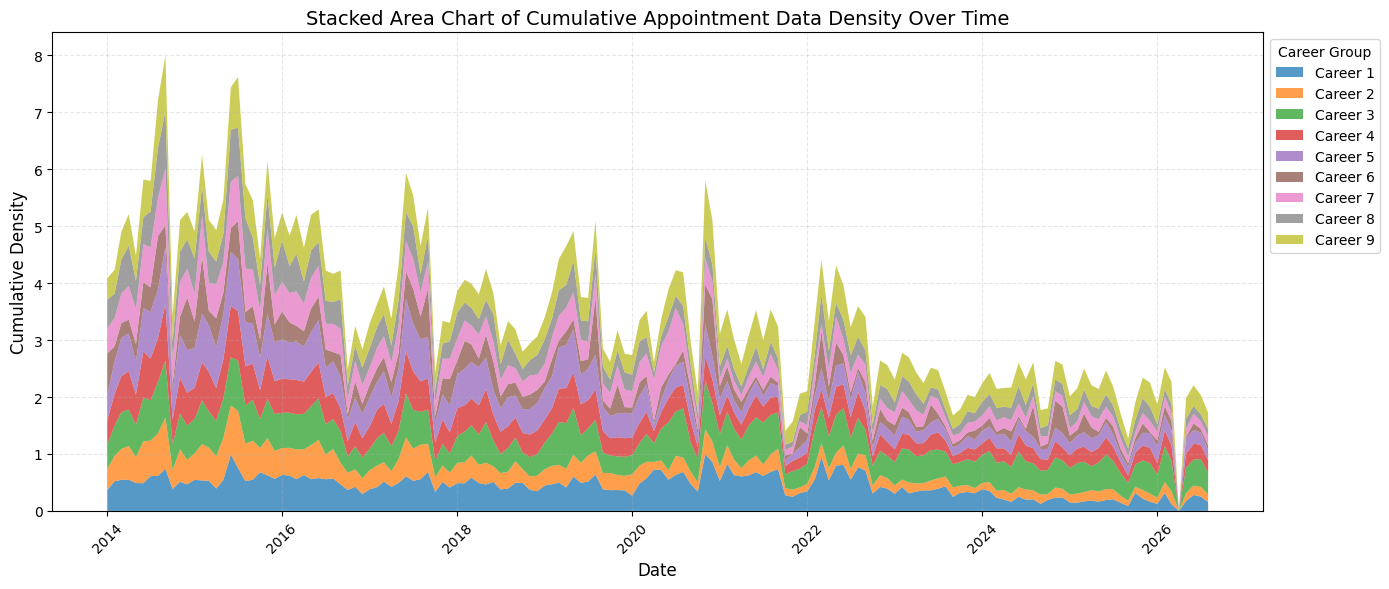

In [280]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot stacked area chart for Job Appointments (Hired Applicants)
plt.stackplot(
    df_appointment_t_norm.columns,
    df_appointment_t_norm.astype(float).values,
    labels=[f'Career {c}' for c in df_appointment_t_norm.index],
    alpha=0.75
)

plt.title('Stacked Area Chart of Cumulative Appointment Data Density Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Density', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Career Group')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

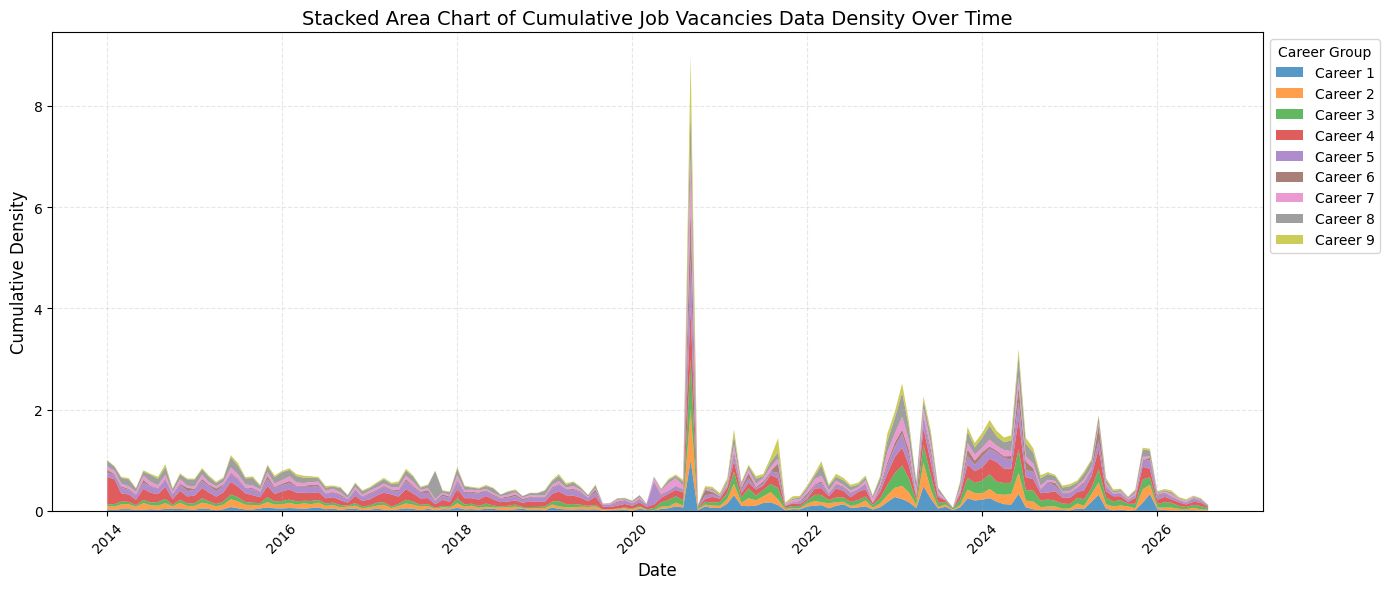

In [281]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot stacked area chart for Job Vacancies (Available Careers)
plt.stackplot(
    df_avaliable_t_norm.columns,
    df_avaliable_t_norm.astype(float).values,
    labels=[f'Career {c}' for c in df_avaliable_t_norm.index],
    alpha=0.75
)

plt.title('Stacked Area Chart of Cumulative Job Vacancies Data Density Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Density', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Career Group')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# **พบความผิดกติของข้อมูล**

# **ทำ Data Smoothing**

In [282]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------------
# เซลล์ที่ 1: แก้ปัญหายอดแหลมปี 2020 (df_avaliable_career_t)
# ---------------------------------------------------------

df_avaliable_float = df_avaliable_career_t.astype(float)
df_avaliable_capped = df_avaliable_float.copy()

# หาค่า Percentile ที่ 90 ของแต่ละอาชีพ และตัดยอดให้เท่ากับเพดาน
for career in df_avaliable_capped.index:
    p90 = np.percentile(df_avaliable_capped.loc[career], 90)
    df_avaliable_capped.loc[career] = df_avaliable_capped.loc[career].clip(upper=p90)

# ทำ Normalize (0-1) ให้กับข้อมูลตำแหน่งงานว่างที่แก้แล้ว
scaler_avail = MinMaxScaler()
df_avaliable_t_norm_fixed = pd.DataFrame(
    scaler_avail.fit_transform(df_avaliable_capped.T).T,
    index=df_avaliable_capped.index,
    columns=df_avaliable_capped.columns
)

print("✅ จัดการ Outlier ตำแหน่งงานว่าง ปี 2020 เสร็จสิ้น (df_avaliable_t_norm_fixed)")

✅ จัดการ Outlier ตำแหน่งงานว่าง ปี 2020 เสร็จสิ้น (df_avaliable_t_norm_fixed)


In [283]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def process_two_structural_breaks(df, cap_percentile=98):
    df_fixed = df.copy().astype(float)
    dates = pd.to_datetime(df_fixed.columns)

    # กำหนดช่วงเวลา (Masks)
    mask_before_2016 = dates < pd.to_datetime('2016-07-01')
    mask_after_2020 = dates >= pd.to_datetime('2020-01-01')

    # ---------------------------------------------------
    # 1. จัดการจุดหักเหที่ 1 (กดปี 2014-2016 ลงมาหาฐานปี 17-19)
    # ---------------------------------------------------
    mean_before_16 = df_fixed.loc[:, dates < pd.to_datetime('2016-01-01')].mean(axis=1)
    mean_baseline = df_fixed.loc[:, (dates >= pd.to_datetime('2017-01-01')) & (dates < pd.to_datetime('2019-01-01'))].mean(axis=1)

    ratio_16 = mean_baseline / mean_before_16
    for col in df_fixed.columns[mask_before_2016]:
        df_fixed[col] = df_fixed[col] * ratio_16

    # ---------------------------------------------------
    # 2. จัดการจุดหักเหที่ 2 (กดปี 2020-2026 ลงมาหาฐานปี 17-19)
    # ---------------------------------------------------
    # หาค่าเฉลี่ยของช่วงที่ยกฐานสูงขึ้น (ใช้ช่วงปี 2021-2023 เป็นตัวแทน)
    mean_elevated_20 = df_fixed.loc[:, (dates >= pd.to_datetime('2021-01-01')) & (dates < pd.to_datetime('2024-01-01'))].mean(axis=1)

    ratio_20 = mean_baseline / mean_elevated_20
    for col in df_fixed.columns[mask_after_2020]:
        df_fixed[col] = df_fixed[col] * ratio_20

    # ---------------------------------------------------
    # 3. ตัดยอด Outlier แหลมๆ (Winsorization) เล็กน้อยเผื่อไว้
    # ---------------------------------------------------
    for career in df_fixed.index:
        p_cap = np.percentile(df_fixed.loc[career], cap_percentile)
        df_fixed.loc[career] = df_fixed.loc[career].clip(upper=p_cap)

    # ---------------------------------------------------
    # 4. Normalize (0-1) ให้พร้อมใช้งานสำหรับ Machine Learning
    # ---------------------------------------------------
    scaler = MinMaxScaler()
    df_norm = pd.DataFrame(
        scaler.fit_transform(df_fixed.T).T,
        index=df_fixed.index,
        columns=df_fixed.columns
    )
    return df_norm

# ========================================================
# นำฟังก์ชันมาใช้งานกับข้อมูล
# ========================================================
df_applicant_t_norm_fixed = process_two_structural_breaks(df_applicant_career_t)
df_appointment_t_norm_fixed = process_two_structural_breaks(df_appointment_career_t)

print("✅ แก้ปัญหาฐานข้อมูล 2 จุด (2016 และ 2020) พร้อม Normalize เสร็จสิ้น!")

✅ แก้ปัญหาฐานข้อมูล 2 จุด (2016 และ 2020) พร้อม Normalize เสร็จสิ้น!


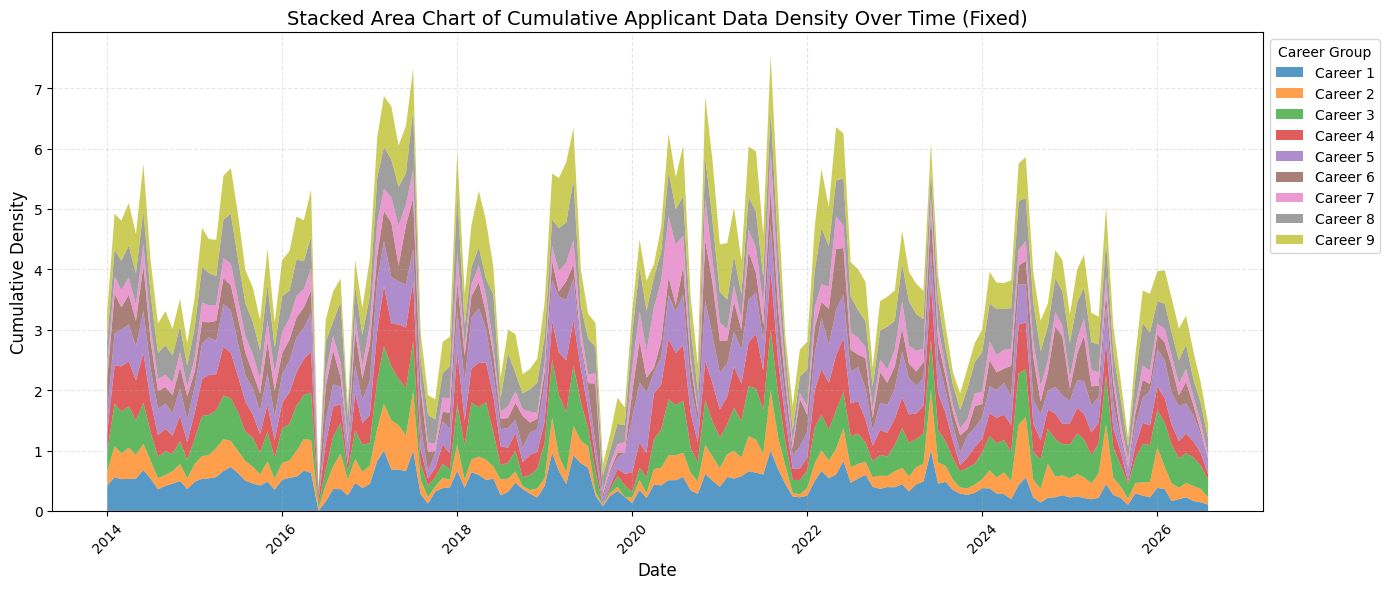

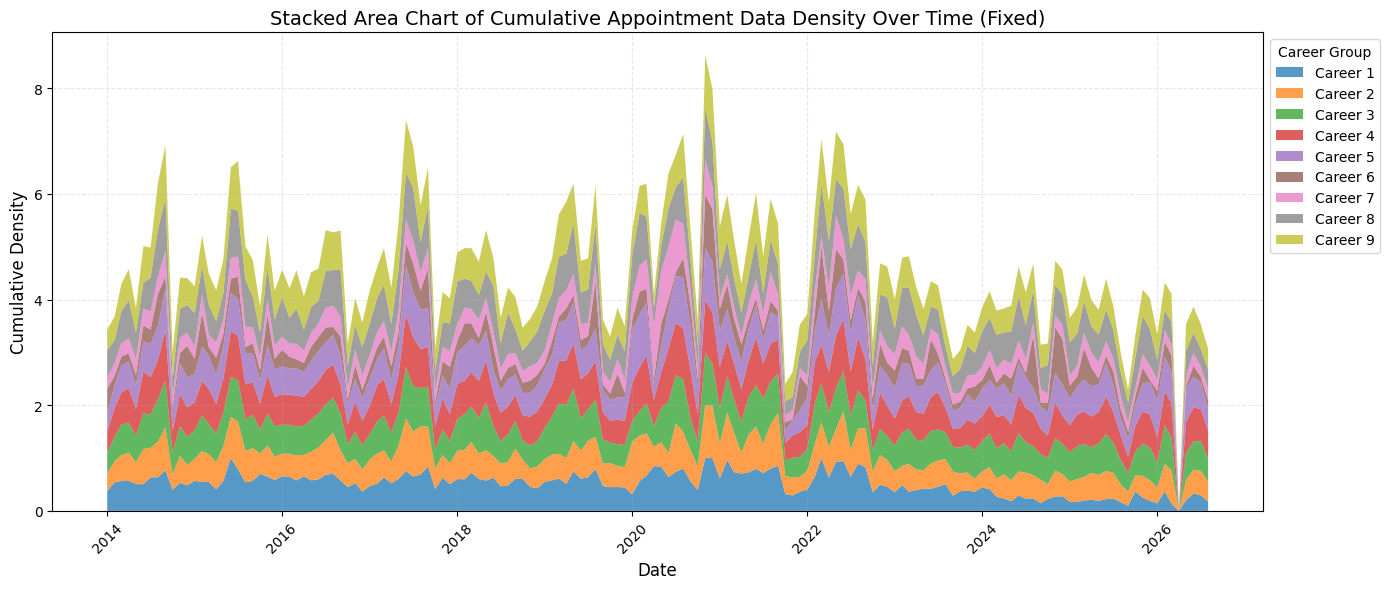

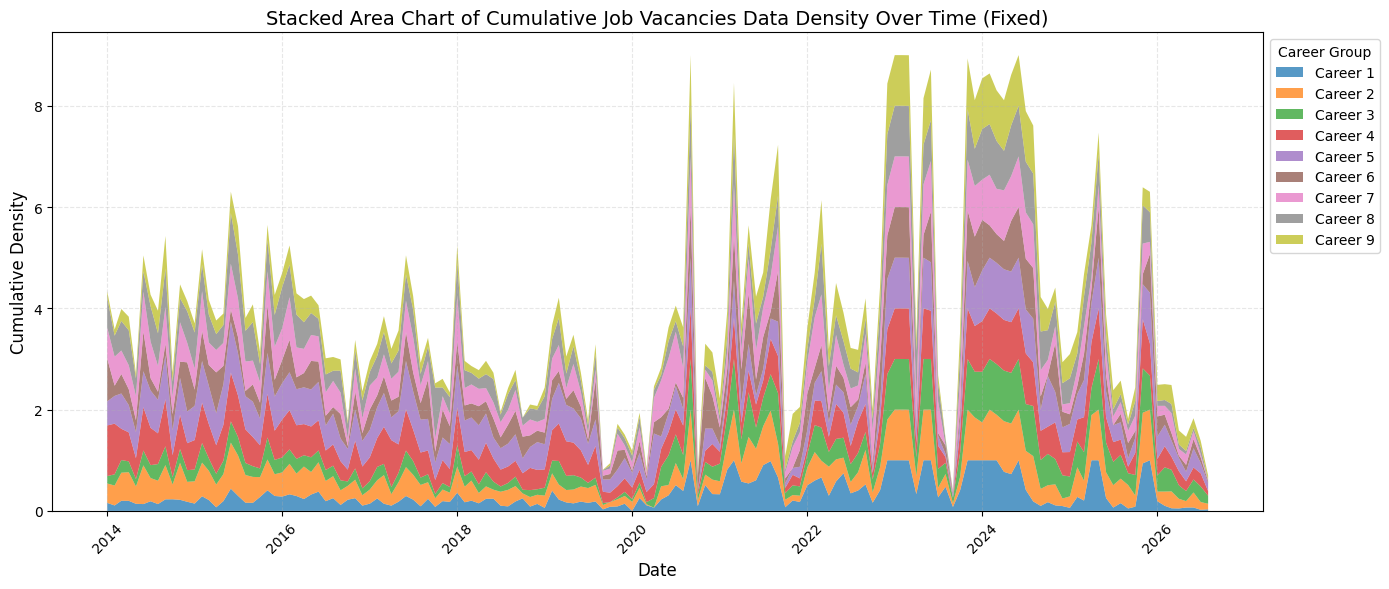

In [284]:
import matplotlib.pyplot as plt

# รวบรวมชุดข้อมูลที่จัดการ Outlier และ Structural Break แล้ว
datasets_fixed = {
    'Applicants': (df_applicant_t_norm_fixed, 'Stacked Area Chart of Cumulative Applicant Data Density Over Time (Fixed)'),
    'Appointments': (df_appointment_t_norm_fixed, 'Stacked Area Chart of Cumulative Appointment Data Density Over Time (Fixed)'),
    'Job Vacancies': (df_avaliable_t_norm_fixed, 'Stacked Area Chart of Cumulative Job Vacancies Data Density Over Time (Fixed)')
}

for key, (df_norm, title_text) in datasets_fixed.items():
    plt.figure(figsize=(14, 6))

    # พล็อตพื้นที่สะสม
    plt.stackplot(
        df_norm.columns,
        df_norm.astype(float).values,
        labels=[f'Career {c}' for c in df_norm.index],
        alpha=0.75
    )

    plt.title(title_text, fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Cumulative Density', fontsize=12)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Career Group')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [285]:
import pandas as pd

def prepare_datetime_for_ml(df):
    df_prepared = df.copy()

    print(f"📌 ชนิดข้อมูลวันที่ (ก่อนแปลง): {type(df_prepared.columns[0])}")

    # 1. แปลงชื่อคอลัมน์ที่เป็นวันที่ ให้เป็นชนิด Datetime อย่างเป็นทางการ
    df_prepared.columns = pd.to_datetime(df_prepared.columns)
    print(f"✅ ชนิดข้อมูลวันที่ (หลังแปลง): {type(df_prepared.columns[0])}")

    # 2. เรียงลำดับวันที่จากอดีตไปอนาคต (ป้องกันข้อมูลสลับเดือนกัน)
    df_prepared = df_prepared.sort_index(axis=1)

    # 3. หมุนแกน (Transpose) ให้ 'วันที่' เป็น Index (แถว) และ 'อาชีพ' เป็น Column
    # (นี่คือ Format มาตรฐานบังคับสำหรับ Scikit-Learn, Statsmodels, TensorFlow)
    df_ml_ready = df_prepared.T

    # 4. ตรวจสอบความสม่ำเสมอของเวลา (ถ้ามีเดือนไหนแหว่งไปจะได้รู้)
    # หากข้อมูลมาทุกเดือนสม่ำเสมอ Index ควรต่อเนื่องกัน
    missing_dates = pd.date_range(start=df_ml_ready.index.min(),
                                  end=df_ml_ready.index.max(),
                                  freq='MS').difference(df_ml_ready.index)

    if len(missing_dates) == 0:
        print("✅ ข้อมูลเวลาต่อเนื่องสมบูรณ์ ไม่มีเดือนใดสูญหาย")
    else:
        print(f"⚠️ พบเดือนที่ข้อมูลขาดหายไป: {missing_dates}")

    print("-" * 50)
    return df_ml_ready

# ========================================================
# นำฟังก์ชันมาใช้งาน
# ========================================================
print("--- สรุปการเตรียมข้อมูลผู้สมัคร (Applicant) ---")
df_applicant_ml = prepare_datetime_for_ml(df_applicant_t_norm_fixed)

print("\n--- สรุปการเตรียมข้อมูลผู้บรรจุ (Appointment) ---")
df_appointment_ml = prepare_datetime_for_ml(df_appointment_t_norm_fixed)

df_avaliable_ml = prepare_datetime_for_ml(df_avaliable_t_norm_fixed)

# ลองดูหน้าตาข้อมูลที่พร้อมเทรน
display(df_applicant_ml.head())

--- สรุปการเตรียมข้อมูลผู้สมัคร (Applicant) ---
📌 ชนิดข้อมูลวันที่ (ก่อนแปลง): <class 'pandas._libs.tslibs.timestamps.Timestamp'>
✅ ชนิดข้อมูลวันที่ (หลังแปลง): <class 'pandas._libs.tslibs.timestamps.Timestamp'>
✅ ข้อมูลเวลาต่อเนื่องสมบูรณ์ ไม่มีเดือนใดสูญหาย
--------------------------------------------------

--- สรุปการเตรียมข้อมูลผู้บรรจุ (Appointment) ---
📌 ชนิดข้อมูลวันที่ (ก่อนแปลง): <class 'pandas._libs.tslibs.timestamps.Timestamp'>
✅ ชนิดข้อมูลวันที่ (หลังแปลง): <class 'pandas._libs.tslibs.timestamps.Timestamp'>
✅ ข้อมูลเวลาต่อเนื่องสมบูรณ์ ไม่มีเดือนใดสูญหาย
--------------------------------------------------
📌 ชนิดข้อมูลวันที่ (ก่อนแปลง): <class 'pandas._libs.tslibs.timestamps.Timestamp'>
✅ ชนิดข้อมูลวันที่ (หลังแปลง): <class 'pandas._libs.tslibs.timestamps.Timestamp'>
✅ ข้อมูลเวลาต่อเนื่องสมบูรณ์ ไม่มีเดือนใดสูญหาย
--------------------------------------------------


,1,2,3,4,5,6,7,8,9
Date,,,,,,,,,
2014-01-01,0.418141,0.233261,0.331739,0.308823,0.328344,0.558395,0.236457,0.400986,0.475181
2014-02-01,0.558095,0.516723,0.703782,0.630878,0.532464,0.658582,0.277163,0.455000,0.589839
2014-03-01,0.526548,0.425130,0.689443,0.750938,0.606793,0.372332,0.286933,0.482521,0.667170
2014-04-01,0.529416,0.518124,0.686343,0.745907,0.609370,0.489694,0.285124,0.527532,0.705193
2014-05-01,0.534005,0.391798,0.571436,0.662117,0.560711,0.426719,0.263233,0.521616,0.654264


# **Modelling Phase**

# Feature **Engineering**

# **เตรียมข้อมูลและสร้างตัวแปรในอดีต**
คำนวณผลต่าง (Gap) ระหว่างตำแหน่งงานว่างและจำนวนผู้ได้รับการบรรจุ เพื่อใช้เป็นตัวชี้วัดสภาวะตลาดแรงงาน จากนั้นเราจะสร้างตัวแปร "Lag (ข้อมูลย้อนหลัง)" จำนวน 3 เดือน เพื่อให้โมเดล Machine Learning สามารถเรียนรู้แนวโน้มจากอดีตเพื่อทำนายอนาคตได้

In [286]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. กำหนดกลุ่มอาชีพเป้าหมาย (ใช้ String เพื่อป้องกัน KeyError)
career_target = '1'

# 2. คำนวณผลต่างและจัดกลุ่มสถานะ
df_gap = df_avaliable_ml - df_appointment_ml

def categorize_gap(gap_value):
    if gap_value >= 0.15:
        return 'Severe_Shortage'  # ขาดแคลน
    elif gap_value <= -0.15:
        return 'Oversupply'       # ล้นตลาด
    else:
        return 'Balanced'         # สมดุล

gap_series = df_gap[career_target].apply(categorize_gap)

# 3. สร้างตารางรวมข้อมูลสำหรับเทรนโมเดล
df_model = pd.DataFrame({
    'Vacancies': df_avaliable_ml[career_target],
    'Appointments': df_appointment_ml[career_target],
    'Target_Class': gap_series
})

# 4. สร้าง Lag ย้อนหลัง 3 เดือน (เดือนที่ t-1, t-2, t-3)
for i in [1, 2, 3]:
    df_model[f'Vac_Lag_{i}'] = df_model['Vacancies'].shift(i)
    df_model[f'App_Lag_{i}'] = df_model['Appointments'].shift(i)

# ตัดแถวแรกๆ ที่ไม่มีข้อมูลอดีต (NaN) ทิ้ง
df_model = df_model.dropna()

# 5. กำหนดตัวแปรต้น (X) และแบ่ง Train/Test 80:20 แบบตามลำดับเวลา
feature_cols = ['Vac_Lag_1', 'App_Lag_1', 'Vac_Lag_2', 'App_Lag_2', 'Vac_Lag_3', 'App_Lag_3']
X = df_model[feature_cols]

split_idx = int(len(X) * 0.8)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

print("✅ เตรียมข้อมูลและแบ่ง Train/Test เสร็จสมบูรณ์")
print(f"จำนวนข้อมูล Train: {len(X_train)} เดือน, Test: {len(X_test)} เดือน")

✅ เตรียมข้อมูลและแบ่ง Train/Test เสร็จสมบูรณ์
จำนวนข้อมูล Train: 119 เดือน, Test: 30 เดือน


# **Model 1 - พยากรณ์ตัวเลขแล้วแปลงผล (Regression + Rule-based)**
ใช้ Linear Regression พยากรณ์ "ตัวเลข" ของ Vacancies และ Appointments ในเดือนถัดไปแยกกันสองเส้น เมื่อได้ตัวเลขพยากรณ์มาแล้ว เราจะนำมาลบกันเพื่อหาค่า Gap พยากรณ์ และใช้เงื่อนไขคณิตศาสตร์ (Rule-based) ที่เราตั้งไว้เพื่อจัดว่าเดือนนั้นจะตกอยู่ในสถานะใด

In [287]:
# แยกเป้าหมาย (y) เป็นตัวเลขดิบ สำหรับพยากรณ์แยกกัน
y_train_vac = df_model['Vacancies'].iloc[:split_idx]
y_test_vac = df_model['Vacancies'].iloc[split_idx:]

y_train_app = df_model['Appointments'].iloc[:split_idx]
y_test_app = df_model['Appointments'].iloc[split_idx:]

# 1. เทรนโมเดล Linear Regression
reg_vac = LinearRegression().fit(X_train, y_train_vac)
reg_app = LinearRegression().fit(X_train, y_train_app)

# 2. ทำนายตัวเลข
pred_vac = reg_vac.predict(X_test)
pred_app = reg_app.predict(X_test)

# 3. นำตัวเลขทำนายมาลบกัน แล้วแปลงเป็น Class
pred_gap_reg = pred_vac - pred_app
pred_class_model1 = [categorize_gap(g) for g in pred_gap_reg]

print("✅ เทรนและทำนายผลด้วย Model 1 (Regression) เสร็จสมบูรณ์")

✅ เทรนและทำนายผลด้วย Model 1 (Regression) เสร็จสมบูรณ์


# **Model 2 - สายพยากรณ์สถานะโดยตรง (Direct Classification)**
ใช้โมเดล Random Forest ซึ่งเป็นกลุ่ม Tree-based ให้เรียนรู้ความสัมพันธ์ของข้อมูลย้อนหลัง และพยากรณ์ "สถานะ (Class)" ออกมาโดยตรง

In [288]:
# แยกเป้าหมาย (y) เป็น Class (Severe_Shortage, Balanced, Oversupply) โดยตรง
y_train_class = df_model['Target_Class'].iloc[:split_idx]
y_test_class = df_model['Target_Class'].iloc[split_idx:]

# 1. เทรนโมเดล Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_clf.fit(X_train, y_train_class)

# 2. ทำนายสถานะโดยตรง
pred_class_model2 = rf_clf.predict(X_test)

print("✅ เทรนและทำนายผลด้วย Model 2 (Random Forest) เสร็จสมบูรณ์")

✅ เทรนและทำนายผลด้วย Model 2 (Random Forest) เสร็จสมบูรณ์


# **ประเมินประสิทธิภาพเปรียบเทียบและการดึงปัจจัยสำคัญ**
รายงานความแม่นยำ (Classification Report) เพื่อเปรียบเทียบว่าโมเดลไหนทายสถานะได้แม่นยำกว่ากัน นอกจากนี้ เราจะดึง Feature Importance จาก Random Forest มาดูว่า ข้อมูลของกี่เดือนที่แล้วที่เป็นตัวแปรสำคัญที่สุดในการตัดสินใจของโมเดล

ผลลัพธ์ Model 1: Regression + Rule-based
                 precision    recall  f1-score   support

       Balanced       0.57      0.57      0.57        14
     Oversupply       0.29      0.29      0.29         7
Severe_Shortage       0.78      0.78      0.78         9

       accuracy                           0.57        30
      macro avg       0.54      0.54      0.54        30
   weighted avg       0.57      0.57      0.57        30


ผลลัพธ์ Model 2: Direct Classification (Random Forest)
                 precision    recall  f1-score   support

       Balanced       0.50      0.79      0.61        14
     Oversupply       0.00      0.00      0.00         7
Severe_Shortage       0.62      0.56      0.59         9

       accuracy                           0.53        30
      macro avg       0.38      0.45      0.40        30
   weighted avg       0.42      0.53      0.46        30



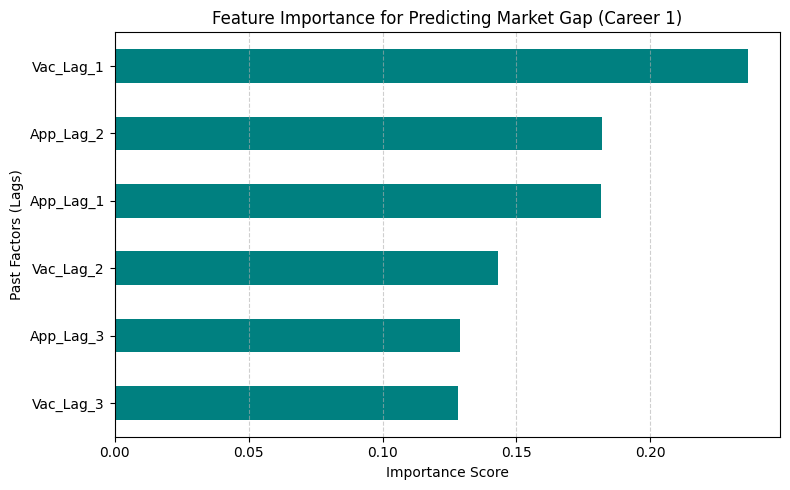

In [289]:
# 1. เปรียบเทียบ Classification Report
print("="*50)
print("ผลลัพธ์ Model 1: Regression + Rule-based")
print("="*50)
print(classification_report(y_test_class, pred_class_model1, zero_division=0))

print("\n" + "="*50)
print("ผลลัพธ์ Model 2: Direct Classification (Random Forest)")
print("="*50)
print(classification_report(y_test_class, pred_class_model2, zero_division=0))

# 2. ดูความสำคัญของปัจจัย (Feature Importance) จาก Model 2
importance = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color='teal')
plt.title(f'Feature Importance for Predicting Market Gap (Career {career_target})')
plt.xlabel('Importance Score')
plt.ylabel('Past Factors (Lags)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# **ปัญหาจากผลลัพธ์**
# - Model 2 (Random Forest) ได้คะแนน Oversupply เป็น 0.00: โมเดลเกิดอาการ "ขี้เกียจเรียนรู้" เพราะในข้อมูล 30 เดือนที่ใช้ทดสอบ มีสภาวะ Oversupply เพียง 7 เดือน โมเดลจึงเลือกที่จะทายว่าเป็น Balanced (ซึ่งมีเยอะสุดคือ 14 เดือน) เพื่อดึงค่าความแม่นยำรวมให้สูงขึ้น แทนที่จะเสี่ยงทายคลาสที่เกิดยาก


# - Model 1 (Linear Regression ธรรมดา) พลาดคลาส Oversupply เช่นกัน (F1 = 0.29): การใช้ข้อมูลย้อนหลัง (Lags) 1, 2, 3 เดือน มักจะมีค่าตัวเลขที่วิ่งล้อตามกัน (Correlated) ทำให้ Linear Regression ธรรมดาสับสนและให้น้ำหนักตัวแปรผิดเพี้ยน

# **สิ่งที่จะปรับแก้**
# - อัปเกรด Model 1 เป็น Ridge Regression: เพิ่มตัวควบคุมสมการ (Regularization) เพื่อลดผลกระทบจากตัวแปร Lags ที่ซ้ำซ้อนกัน ทำให้เส้นพยากรณ์นิ่งขึ้น

# - อัปเกรด Model 2 ด้วย class_weight='balanced': บังคับให้ Random Forest ลงโทษตัวเองหนักขึ้นหากทายคลาสที่มีข้อมูลน้อย (Oversupply และ Severe_Shortage) ผิด และปรับ max_depth ให้ตื้นลงเพื่อลดการจำเจาะจง (Overfitting) กับข้อมูล Train มากเกินไป

In [290]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ==========================================
# Tuned Model 1: Ridge Regression + Rule-based
# ==========================================
# ใช้ Ridge แทน LinearRegression เพื่อลดปัญหาตัวแปร Lags ซ้อนทับกัน
ridge_vac = Ridge(alpha=1.0).fit(X_train, y_train_vac)
ridge_app = Ridge(alpha=1.0).fit(X_train, y_train_app)

pred_vac_tuned = ridge_vac.predict(X_test)
pred_app_tuned = ridge_app.predict(X_test)

pred_gap_tuned = pred_vac_tuned - pred_app_tuned
pred_class_m1_tuned = [categorize_gap(g) for g in pred_gap_tuned]

# ==========================================
# Tuned Model 2: Random Forest (Balanced)
# ==========================================
# เพิ่ม class_weight='balanced' และปรับลด max_depth ลง
rf_tuned = RandomForestClassifier(
    n_estimators=200,          # เพิ่มจำนวนต้นไม้ให้ออกเสียงแม่นยำขึ้น
    max_depth=4,               # ลดความลึกไม่ให้โมเดลจำข้อสอบ
    class_weight='balanced',   # **หัวใจสำคัญ: บังคับให้สนใจคลาสส่วนน้อย**
    random_state=42
)
rf_tuned.fit(X_train, y_train_class)

pred_class_m2_tuned = rf_tuned.predict(X_test)

# ==========================================
# แสดงผลลัพธ์เปรียบเทียบ
# ==========================================
print("=== ผลลัพธ์ Tuned Model 1: Ridge Regression ===")
print(classification_report(y_test_class, pred_class_m1_tuned, zero_division=0))

print("\n=== ผลลัพธ์ Tuned Model 2: Random Forest (Balanced) ===")
print(classification_report(y_test_class, pred_class_m2_tuned, zero_division=0))

=== ผลลัพธ์ Tuned Model 1: Ridge Regression ===
                 precision    recall  f1-score   support

       Balanced       0.67      0.57      0.62        14
     Oversupply       0.44      0.57      0.50         7
Severe_Shortage       0.78      0.78      0.78         9

       accuracy                           0.63        30
      macro avg       0.63      0.64      0.63        30
   weighted avg       0.65      0.63      0.64        30


=== ผลลัพธ์ Tuned Model 2: Random Forest (Balanced) ===
                 precision    recall  f1-score   support

       Balanced       0.47      0.57      0.52        14
     Oversupply       0.00      0.00      0.00         7
Severe_Shortage       0.67      0.67      0.67         9

       accuracy                           0.47        30
      macro avg       0.38      0.41      0.39        30
   weighted avg       0.42      0.47      0.44        30



เราสามารถตัด Random Forest ทิ้ง และเลือกใช้ Ridge Regression + Rule-based เป็นโมเดลหลักได้อย่างมั่นใจครับ เพราะสอดคล้องกับธรรมชาติของข้อมูลความสัมพันธ์ระหว่างอุปสงค์-อุปทานมากที่สุด

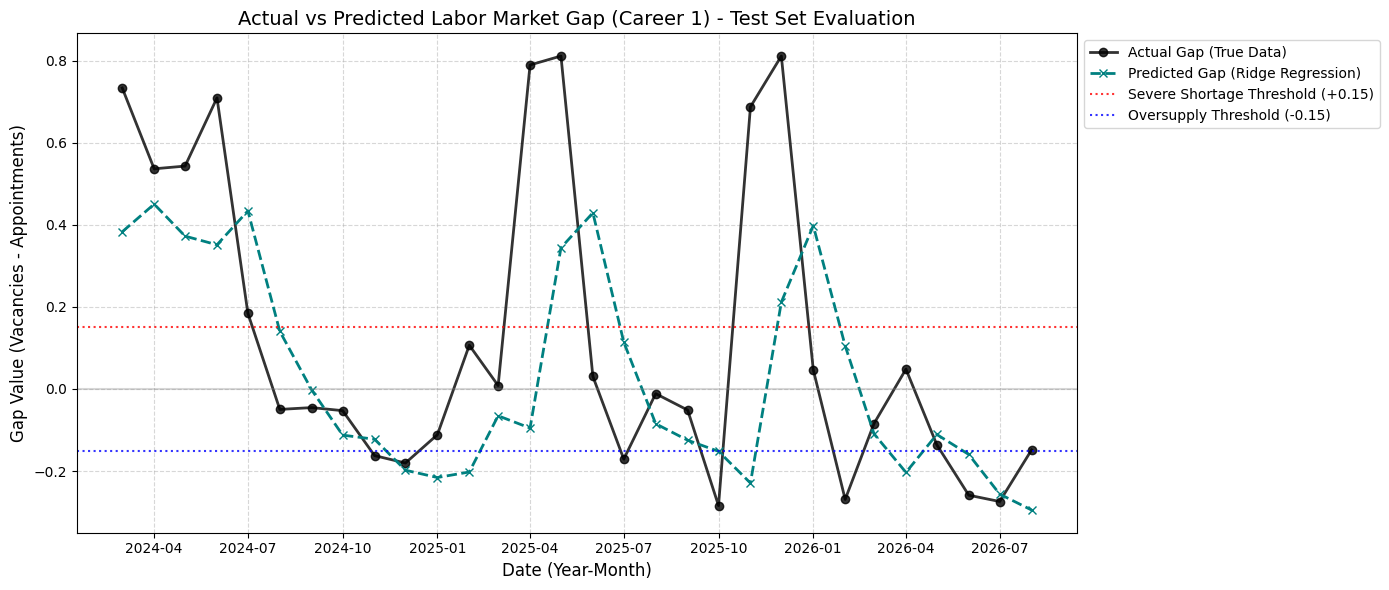

In [291]:
import matplotlib.pyplot as plt

# 1. ดึงข้อมูลวันที่จาก Index ของชุดทดสอบ (X_test)
test_dates = X_test.index

# 2. ดึงค่า Gap จริง (Actual Gap) เฉพาะช่วงเวลาที่ใช้ทดสอบ
actual_gap = df_gap[career_target].loc[test_dates]

# 3. ตั้งค่าขนาดกราฟ
plt.figure(figsize=(14, 6))

# 4. พล็อตเส้นค่าจริง (สีดำทึบ)
plt.plot(test_dates, actual_gap, label='Actual Gap (True Data)',
         color='black', marker='o', linestyle='-', linewidth=2, alpha=0.8)

# 5. พล็อตเส้นค่าพยากรณ์จาก Ridge Regression (สีเขียวอมฟ้า เส้นประ)
plt.plot(test_dates, pred_gap_tuned, label='Predicted Gap (Ridge Regression)',
         color='teal', marker='x', linestyle='--', linewidth=2)

# 6. เพิ่มเส้นแบ่งเกณฑ์สถานะตลาดแรงงาน (Thresholds) ที่เราตั้งไว้ที่ +/- 0.15
plt.axhline(0.15, color='red', linestyle=':', label='Severe Shortage Threshold (+0.15)', alpha=0.8)
plt.axhline(-0.15, color='blue', linestyle=':', label='Oversupply Threshold (-0.15)', alpha=0.8)
plt.axhline(0, color='gray', linestyle='-', alpha=0.3) # เส้นแกนกลาง (0)

# 7. ตกแต่งกราฟให้สวยงามและอ่านง่าย
plt.title(f'Actual vs Predicted Labor Market Gap (Career {career_target}) - Test Set Evaluation', fontsize=14)
plt.xlabel('Date (Year-Month)', fontsize=12)
plt.ylabel('Gap Value (Vacancies - Appointments)', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # ย้ายกล่อง Legend ไปไว้ด้านขวานอกกราฟ
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()

# 8. แสดงผล
plt.show()

# **ข้อสรุป**

โมเดลที่ดีที่สุดสำหรับชุดข้อมูลตลาดแรงงานของคุณคือ Ridge Regression + Rule-based Classification ซึ่งทำหน้าที่เป็น "ระบบพยากรณ์และเตือนภัยล่วงหน้า (Early Warning System)" สำหรับประเมินความตึงเครียดของอุปสงค์และอุปทานแรงงานในแต่ละกลุ่มอาชีพ

# **ข้อมูลนำเข้า (Input)**
โมเดลต้องการตัวแปรตั้งต้นจำนวน 6 ตัวแปร ซึ่งเป็นข้อมูลในอดีต (Lag) ของกลุ่มอาชีพเป้าหมาย ประกอบด้วย:

- ข้อมูลย้อนหลัง 1 เดือน: จำนวนตำแหน่งงานว่าง (Vac_Lag_1) และ จำนวนผู้ได้รับการบรรจุ (App_Lag_1)

- ข้อมูลย้อนหลัง 2 เดือน: จำนวนตำแหน่งงานว่าง (Vac_Lag_2) และ จำนวนผู้ได้รับการบรรจุ (App_Lag_2)

- ข้อมูลย้อนหลัง 3 เดือน: จำนวนตำแหน่งงานว่าง (Vac_Lag_3) และ จำนวนผู้ได้รับการบรรจุ (App_Lag_3)
(หมายเหตุ: ข้อมูลทั้งหมดต้องผ่านการทำ Normalize ให้อยู่ในสเกล 0-1 และปรับแก้ Structural Breaks แล้ว)

# **กระบวนการทำงานด้านใน (Process)**
- ทำนายตัวเลขดิบ: โมเดล Ridge Regression 2 ตัว จะรับข้อมูลอดีตทั้ง 6 ค่า ไปคำนวณแยกกันเพื่อพยากรณ์ว่า "เดือนหน้า" จะมีตัวเลขตำแหน่งงานว่าง (Vacancies) และผู้ได้รับการบรรจุ (Appointments) อยู่ที่เท่าไร

- คำนวณช่องว่าง: นำตัวเลขพยากรณ์ที่ได้มาเข้าสมการคณิตศาสตร์: Gap = Vacancies - Appointments

- จัดหมวดหมู่: นำค่า Gap ที่คำนวณได้ไปเทียบกับกฎเกณฑ์ (Threshold) ที่ตั้งไว้ที่ระดับ +/- 0.15

# **ผลลัพธ์ที่ได้ (Output)**
ผลลัพธ์หลักที่ผู้ใช้งานจะได้รับคือ สภาวะตลาดแรงงาน (Class) ในเดือนถัดไป ซึ่งแบ่งออกเป็น 3 สถานะ:
- Severe_Shortage (ขาดแคลนรุนแรง): เมื่อค่า Gap >= 0.15 สะท้อนว่าเดือนหน้าองค์กรจะเปิดรับตำแหน่งจำนวนมาก แต่จะไม่สามารถหาคนมาบรรจุได้เพียงพอ

- Balanced (สมดุล): เมื่อค่า Gap อยู่ระหว่าง -0.14 ถึง 0.14 สะท้อนว่าการจ้างงานเดินหน้าไปตามปกติ อัตราคนได้งานสอดคล้องกับตำแหน่งที่เปิด

- Oversupply (คนล้นตลาด): เมื่อค่า Gap <= -0.15 สะท้อนว่ายอดการบรรจุคนสูงกว่าตำแหน่งที่เปิดรับมาก (อาจเกิดจากนโยบายรับคนเกินอัตรา หรือคนแห่มาสมัครจนล้น)
นอกจากนี้ ผู้ใช้ยังสามารถดู ค่า Gap พยากรณ์ (ตัวเลข) เพื่อประเมินระดับความรุนแรงของสถานการณ์เปรียบเทียบกับเดือนอื่นๆ ได้ด้วย

# **การนำไปใช้งานจริง (Business Use Case)**
เมื่อปิดรอบข้อมูลในทุกๆ สิ้นเดือน ฝ่ายทรัพยากรบุคคลหรือผู้วางนโยบายสามารถนำข้อมูลของ 3 เดือนล่าสุดมาป้อนเข้าโมเดล หากผลลัพธ์ (Output) เตือนว่ากลุ่มอาชีพใดกำลังจะเข้าสู่สภาวะ Severe_Shortage ในเดือนหน้า องค์กรสามารถตัดสินใจเชิงรุกได้ทันที เช่น การเพิ่มงบประมาณโฆษณาตำแหน่งงาน การปรับเพิ่มเงินเดือนเริ่มต้น หรือการเร่งกระบวนการสัมภาษณ์ให้เร็วขึ้นเพื่อแย่งชิงตัวผู้สมัครก่อนที่ตลาดจะขาดแคลนจริง